# Notebook 02 — Análisis Exploratorio de Datos (EDA)

**Entrega II · Perfiles Bancarios en Argentina**

Toma como input los tres datasets master generados por el notebook 01 (`dataset_master_dic2023.csv`, `dataset_master_dic2024.csv`, `dataset_master_dic2025.csv`) y produce:

1. **Ingeniería de ratios** — variables derivadas a partir de los balances (ROA, ROE, apalancamiento, cartera irregular, eficiencia, liquidez, etc.). Para comparar bancos de distinto tamaño, los ratios valen más que los totales absolutos.
2. **Univariado** — distribución de las variables clave por corte.
3. **Bivariado** — correlaciones y scatters entre pares relevantes.
4. **Comparación por `tipo_entidad`** — público / privado nacional / extranjero.
5. **Evolución transversal** — medianas por tipo entre los tres cortes (Dic-23 → Dic-24 → Dic-25).

## 1. Setup e ingeniería de ratios

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

PROC = Path("../data/processed")
CORTES = ["dic2023", "dic2024", "dic2025"]
CORTE_LABEL = {"dic2023": "Dic-2023", "dic2024": "Dic-2024", "dic2025": "Dic-2025"}

PALETA = {"publico": "#1f77b4", "privado_nacional": "#2ca02c", "extranjero": "#d62728"}
ORDEN_TIPO = ["publico", "privado_nacional", "extranjero"]

In [2]:
def construir_ratios(df: pd.DataFrame) -> pd.DataFrame:
    """Crea ratios bancarios estándar a partir de las columnas de balance.

    Los nombres originales vienen con espacios (ej. 'A C T I V O') porque el BCRA
    los publica así en las tablas HTML. Acá los renombramos a algo manejable.
    """
    df = df.copy()

    rename = {
        "A C T I V O": "activo",
        "P A S I V O": "pasivo",
        "P A T R I M O N I O N E T O": "patrimonio",
        "R D O S. I N T E G R A L E S A C U M. D E L P E R I O D O": "resultado",
        "DEPÓSITOS": "depositos",
        "PRÉSTAMOS": "prestamos",
        "EFECTIVO Y DEPOSITO EN BANCOS": "efectivo",
        "INGRESOS FINANCIEROS": "ing_fin",
        "EGRESOS FINANCIEROS": "egr_fin",
        "INGRESOS POR SERVICIOS": "ing_serv",
        "EGRESOS POR SERVICIOS": "egr_serv",
        "GASTOS DE ADMINISTRACIÓN": "gastos_adm",
        "Dotación de personal": "dotacion",
        "TOTAL DE FINANCIACIONES Y GARANTIAS OTORGADAS ($)": "financiaciones_totales",
    }
    df = df.rename(columns=rename)

    # Ratios de rentabilidad
    df["roa"] = df["resultado"] / df["activo"] * 100
    df["roe"] = df["resultado"] / df["patrimonio"] * 100

    # Estructura financiera
    df["apalancamiento"] = df["activo"] / df["patrimonio"]
    df["depositos_sobre_activo"] = df["depositos"] / df["activo"] * 100
    df["prestamos_sobre_activo"] = df["prestamos"] / df["activo"] * 100
    df["liquidez"] = df["efectivo"] / df["depositos"] * 100

    # Eficiencia (gastos adm / (margen financiero + ing servicios netos)).
    # Las columnas de egresos y gastos vienen con signo NEGATIVO del scraping
    # (así las publica el BCRA en los estados contables). Por eso usamos abs()
    # para trabajar con magnitudes y que el ratio quede en el rango estándar
    # ~40-80% positivo.
    margen = (df["ing_fin"] - df["egr_fin"].abs()) + (df["ing_serv"] - df["egr_serv"].abs())
    df["eficiencia"] = df["gastos_adm"].abs() / margen * 100

    # Cartera irregular = situaciones 3 + 4 + 5 sobre total de financiaciones.
    # Importante: si el banco no tiene financiaciones reportadas (mayoristas,
    # de inversión, sucursales chicas) dejamos NaN en vez de 0, porque "0% de
    # cartera mala" es distinto a "no aplica / no tiene cartera minorista".
    sit_cols = [
        "TF.Sit.3: Con problemas/Riesgo medio (%)",
        "TF.Sit.4: Con alto riesgo de insolvencia/Riesgo alto (%)",
        "TF.Sit.5: Irrecuperable (%)",
    ]
    for c in sit_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    cartera = df[sit_cols].sum(axis=1, min_count=1)
    if "financiaciones_totales" in df.columns:
        fin_tot = pd.to_numeric(df["financiaciones_totales"], errors="coerce")
        cartera = cartera.where(fin_tot > 0)
    df["cartera_irregular"] = cartera

    # Activo por empleado — proxy de productividad
    df["activo_por_empleado"] = df["activo"] / df["dotacion"]

    return df


masters = {}
for corte in CORTES:
    raw = pd.read_csv(PROC / f"dataset_master_{corte}.csv")
    raw["corte"] = CORTE_LABEL[corte]
    masters[corte] = construir_ratios(raw)

# Panel transversal (long) para análisis de evolución
panel = pd.concat(masters.values(), ignore_index=True)
print("Panel transversal:", panel.shape)
panel[["corte", "tipo_entidad"]].value_counts().unstack(fill_value=0)

Panel transversal: (168, 157)


tipo_entidad,privado_nacional,publico,extranjero
corte,,,
Dic-2023,30,17,9
Dic-2024,30,17,9
Dic-2025,30,17,9


In [3]:
# Vista rápida de los ratios recién calculados para Dic-2024
RATIOS = [
    "activo", "patrimonio", "roa", "roe", "apalancamiento",
    "depositos_sobre_activo", "prestamos_sobre_activo", "liquidez",
    "eficiencia", "cartera_irregular", "activo_por_empleado",
    "dotacion", "n_productos_ofrecidos",
]
masters["dic2024"][["nombre_banco", "tipo_entidad"] + RATIOS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
activo,56.0,3.498964e+09,7.790007e+09,6871161.00,1.392028e+08,4.631051e+08,2.629761e+09,4.796726e+10
patrimonio,56.0,8.636553e+08,2.215308e+09,4706654.00,2.528614e+07,1.367377e+08,4.923817e+08,1.514965e+10
roa,56.0,-1.300000e-01,1.114000e+01,-51.68,1.900000e-01,2.480000e+00,4.470000e+00,1.530000e+01
roe,56.0,3.970000e+00,2.868000e+01,-101.35,8.500000e-01,1.244000e+01,1.677000e+01,5.976000e+01
apalancamiento,56.0,4.620000e+00,2.570000e+00,1.09,3.100000e+00,4.120000e+00,5.450000e+00,1.469000e+01
depositos_sobre_activo,55.0,5.824000e+01,1.734000e+01,0.21,4.853000e+01,6.367000e+01,6.964000e+01,8.943000e+01
prestamos_sobre_activo,55.0,2.916000e+01,1.427000e+01,1.48,2.014000e+01,2.704000e+01,3.686000e+01,8.468000e+01
liquidez,55.0,5.427000e+01,2.352000e+02,1.30,1.308000e+01,2.022000e+01,2.962000e+01,1.762970e+03
eficiencia,56.0,6.267000e+01,6.948000e+01,11.61,2.911000e+01,4.124000e+01,5.823000e+01,4.068700e+02
cartera_irregular,52.0,2.410000e+00,3.640000e+00,0.00,4.300000e-01,1.200000e+00,2.450000e+00,2.023000e+01


## 2. Análisis univariado

Para cada variable clave miramos la distribución (histograma + boxplot) sobre el corte más reciente con datos completos (Dic-2024).

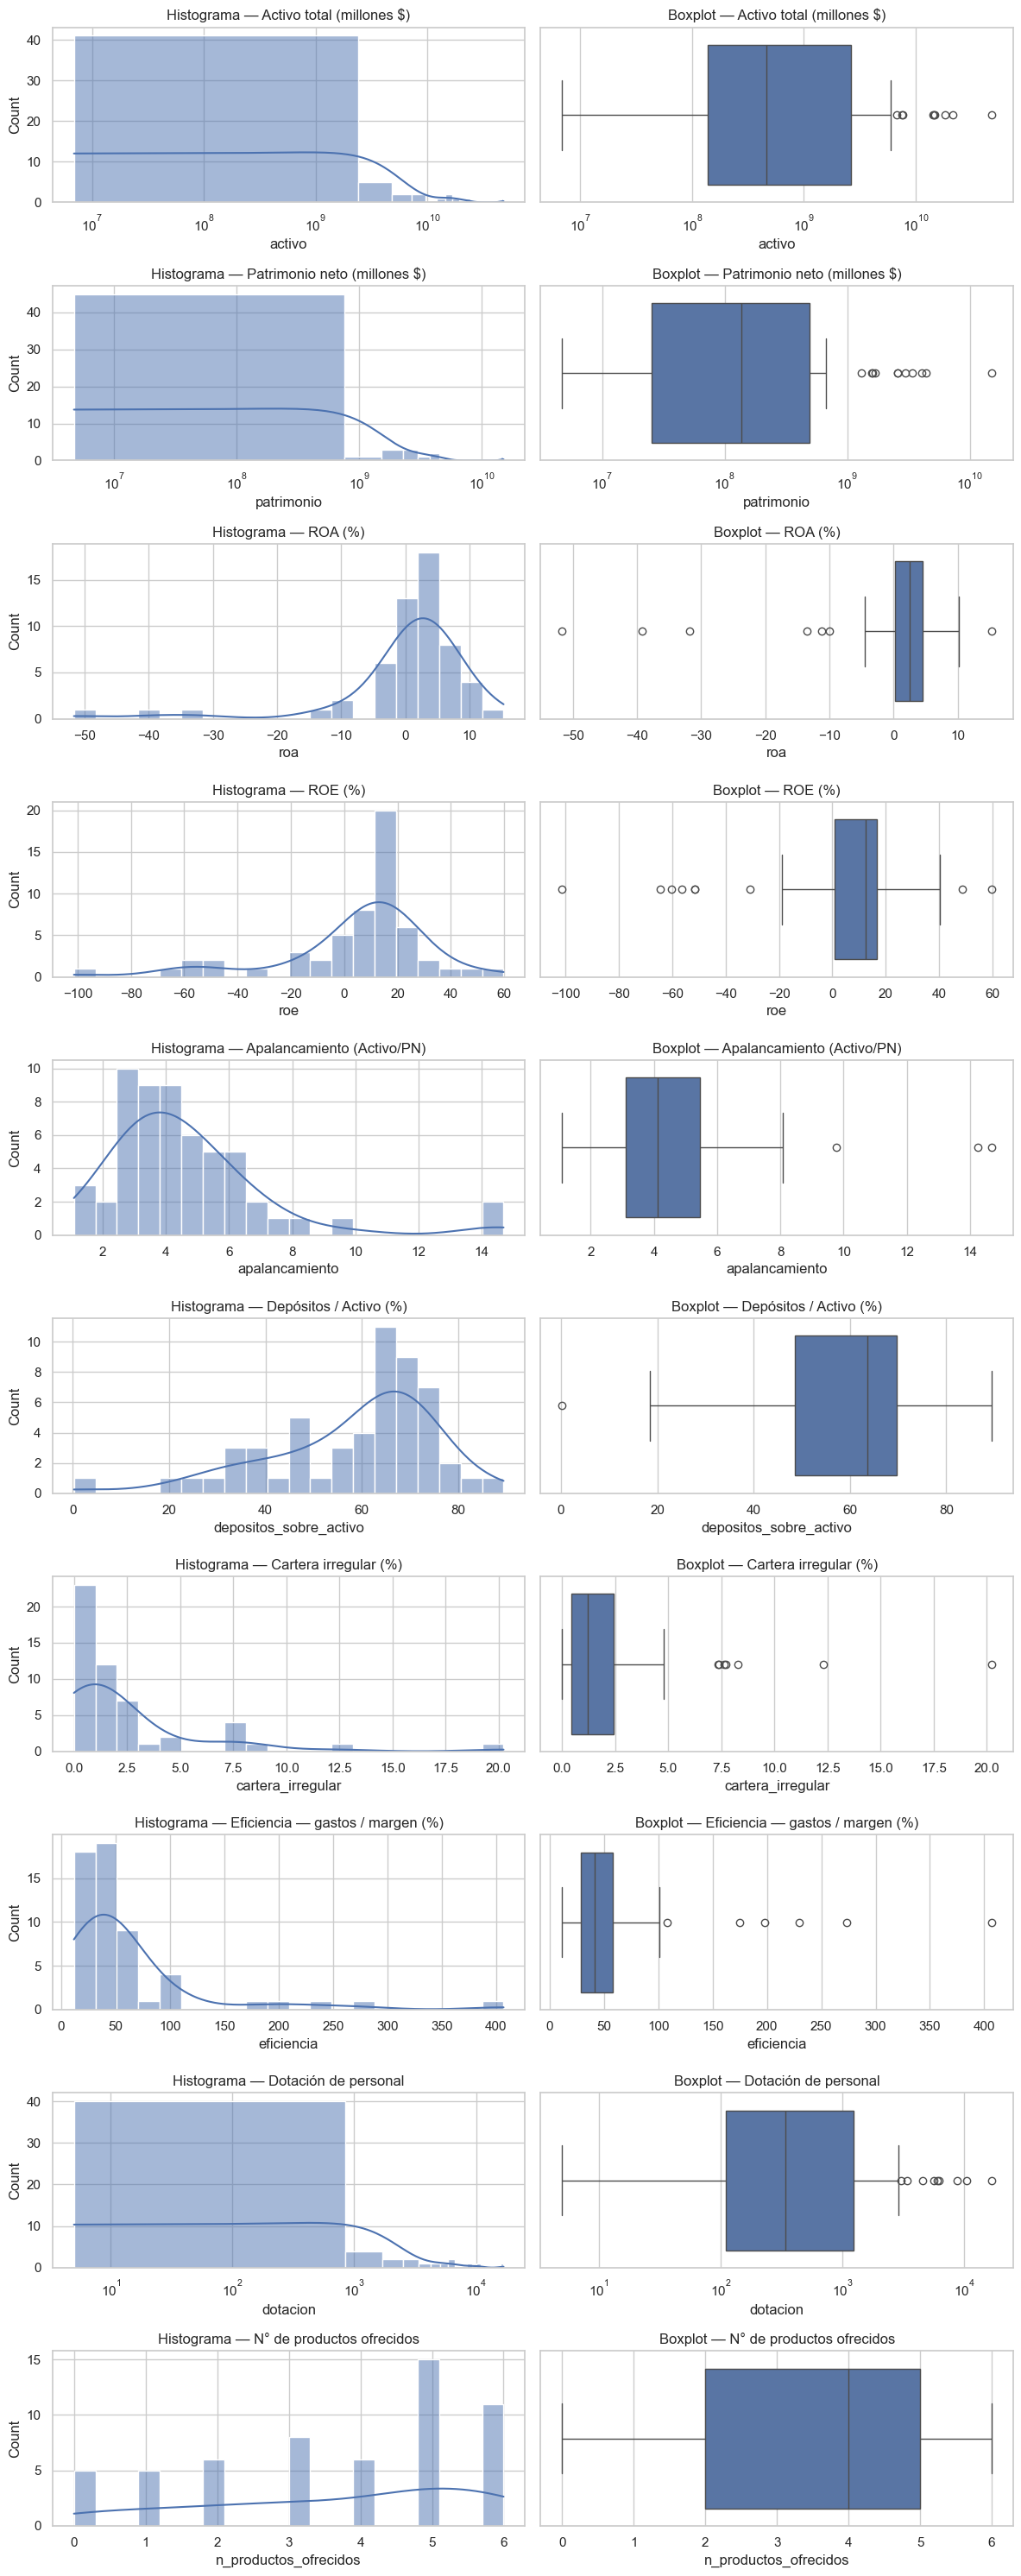

In [4]:
VARS_UNI = [
    ("activo", "Activo total (millones $)", True),
    ("patrimonio", "Patrimonio neto (millones $)", True),
    ("roa", "ROA (%)", False),
    ("roe", "ROE (%)", False),
    ("apalancamiento", "Apalancamiento (Activo/PN)", False),
    ("depositos_sobre_activo", "Depósitos / Activo (%)", False),
    ("cartera_irregular", "Cartera irregular (%)", False),
    ("eficiencia", "Eficiencia — gastos / margen (%)", False),
    ("dotacion", "Dotación de personal", True),
    ("n_productos_ofrecidos", "N° de productos ofrecidos", False),
]

df24 = masters["dic2024"]
fig, axes = plt.subplots(len(VARS_UNI), 2, figsize=(12, 3 * len(VARS_UNI)))
for i, (var, label, log) in enumerate(VARS_UNI):
    serie = df24[var].dropna()
    ax_h, ax_b = axes[i, 0], axes[i, 1]
    sns.histplot(serie, kde=True, ax=ax_h, color="#4C72B0", bins=20)
    ax_h.set_title(f"Histograma — {label}")
    if log and (serie > 0).all():
        ax_h.set_xscale("log")
    sns.boxplot(x=serie, ax=ax_b, color="#4C72B0")
    ax_b.set_title(f"Boxplot — {label}")
    if log and (serie > 0).all():
        ax_b.set_xscale("log")
plt.tight_layout()
plt.show()

## 3. Análisis bivariado

### 3.1 Matriz de correlación (Spearman)

Spearman y no Pearson porque varias variables tienen colas muy pesadas (el activo del Nación es un par de órdenes de magnitud mayor que los bancos chicos) y porque nos interesa la relación monótona, no la lineal.

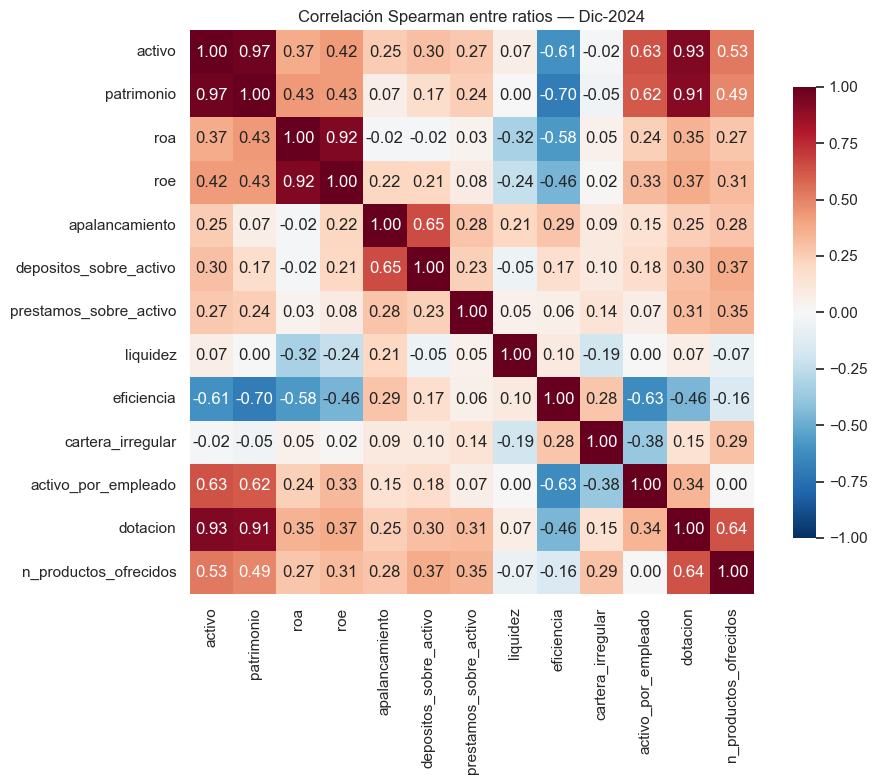

In [5]:
corr = df24[RATIOS].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, vmin=-1, vmax=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlación Spearman entre ratios — Dic-2024")
plt.tight_layout()
plt.show()

### 3.2 Scatters relevantes

Tamaño vs rentabilidad, liquidez vs cartera irregular, depósitos vs préstamos, etc. Los puntos se colorean por `tipo_entidad`.

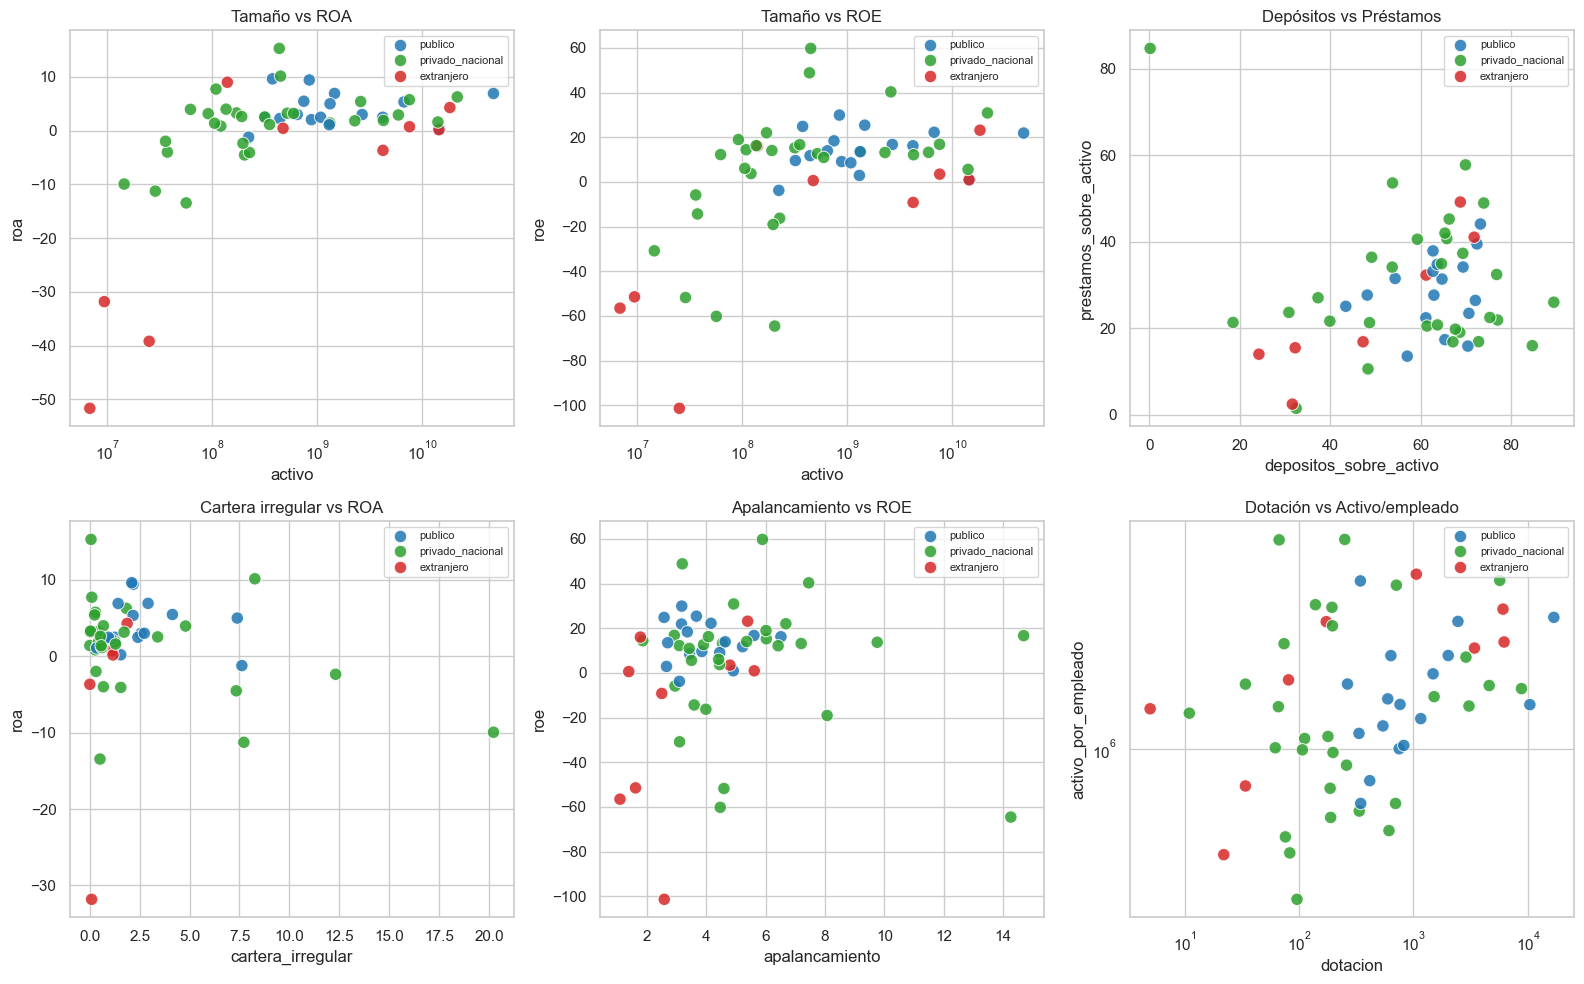

In [6]:
PARES = [
    ("activo", "roa", True, False, "Tamaño vs ROA"),
    ("activo", "roe", True, False, "Tamaño vs ROE"),
    ("depositos_sobre_activo", "prestamos_sobre_activo", False, False, "Depósitos vs Préstamos"),
    ("cartera_irregular", "roa", False, False, "Cartera irregular vs ROA"),
    ("apalancamiento", "roe", False, False, "Apalancamiento vs ROE"),
    ("dotacion", "activo_por_empleado", True, True, "Dotación vs Activo/empleado"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (x, y, logx, logy, titulo) in zip(axes.flat, PARES):
    sns.scatterplot(
        data=df24, x=x, y=y, hue="tipo_entidad", palette=PALETA,
        hue_order=ORDEN_TIPO, s=80, alpha=0.85, ax=ax,
    )
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_title(titulo)
    ax.legend(title="", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Comparación por tipo de entidad

### 4.1 Boxplots por tipo — Dic-2024

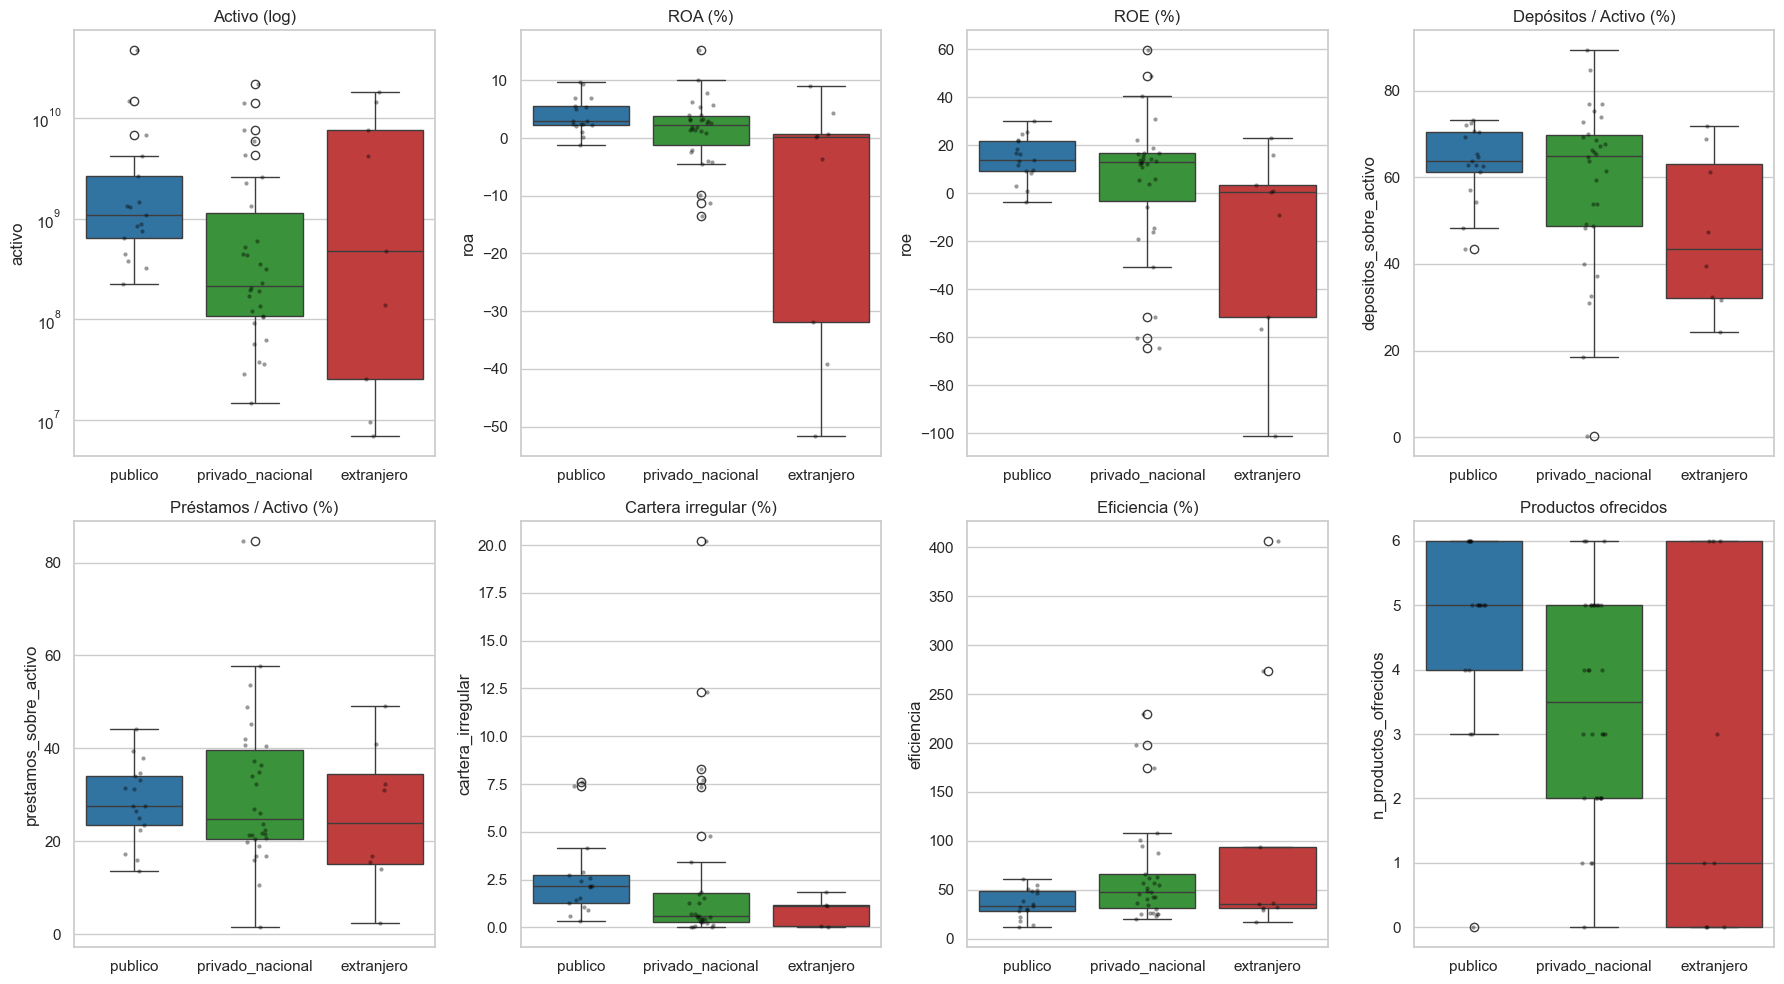

In [7]:
VARS_BOX = [
    ("activo", "Activo (log)", True),
    ("roa", "ROA (%)", False),
    ("roe", "ROE (%)", False),
    ("depositos_sobre_activo", "Depósitos / Activo (%)", False),
    ("prestamos_sobre_activo", "Préstamos / Activo (%)", False),
    ("cartera_irregular", "Cartera irregular (%)", False),
    ("eficiencia", "Eficiencia (%)", False),
    ("n_productos_ofrecidos", "Productos ofrecidos", False),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, (var, label, logy) in zip(axes.flat, VARS_BOX):
    sns.boxplot(
        data=df24, x="tipo_entidad", y=var, order=ORDEN_TIPO,
        palette=PALETA, ax=ax,
    )
    sns.stripplot(
        data=df24, x="tipo_entidad", y=var, order=ORDEN_TIPO,
        color="black", size=3, alpha=0.4, ax=ax,
    )
    if logy:
        ax.set_yscale("log")
    ax.set_title(label)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 4.2 Tabla de medianas por tipo — Dic-2024

Usamos mediana en vez de media porque las distribuciones de tamaño (activo, dotación) son muy asimétricas.

In [8]:
medianas_24 = (
    df24.groupby("tipo_entidad")[RATIOS]
    .median()
    .reindex(ORDEN_TIPO)
    .round(2)
)
medianas_24.T

tipo_entidad,publico,privado_nacional,extranjero
activo,1.085318e+09,2.161131e+08,4.758684e+08
patrimonio,3.158112e+08,4.431319e+07,3.427017e+08
roa,2.990000e+00,2.210000e+00,1.700000e-01
roe,1.393000e+01,1.290000e+01,6.000000e-01
apalancamiento,3.670000e+00,4.510000e+00,2.500000e+00
depositos_sobre_activo,6.367000e+01,6.499000e+01,4.336000e+01
prestamos_sobre_activo,2.766000e+01,2.483000e+01,2.391000e+01
liquidez,1.345000e+01,2.142000e+01,3.310000e+01
eficiencia,3.380000e+01,4.796000e+01,3.554000e+01
cartera_irregular,2.170000e+00,5.800000e-01,1.110000e+00


## 5. Evolución transversal — Dic-2023 · Dic-2024 · Dic-2025

Medianas por tipo de entidad en los tres cortes. Permite ver si las diferencias entre públicos / privados / extranjeros son estructurales o si cambiaron en el período.

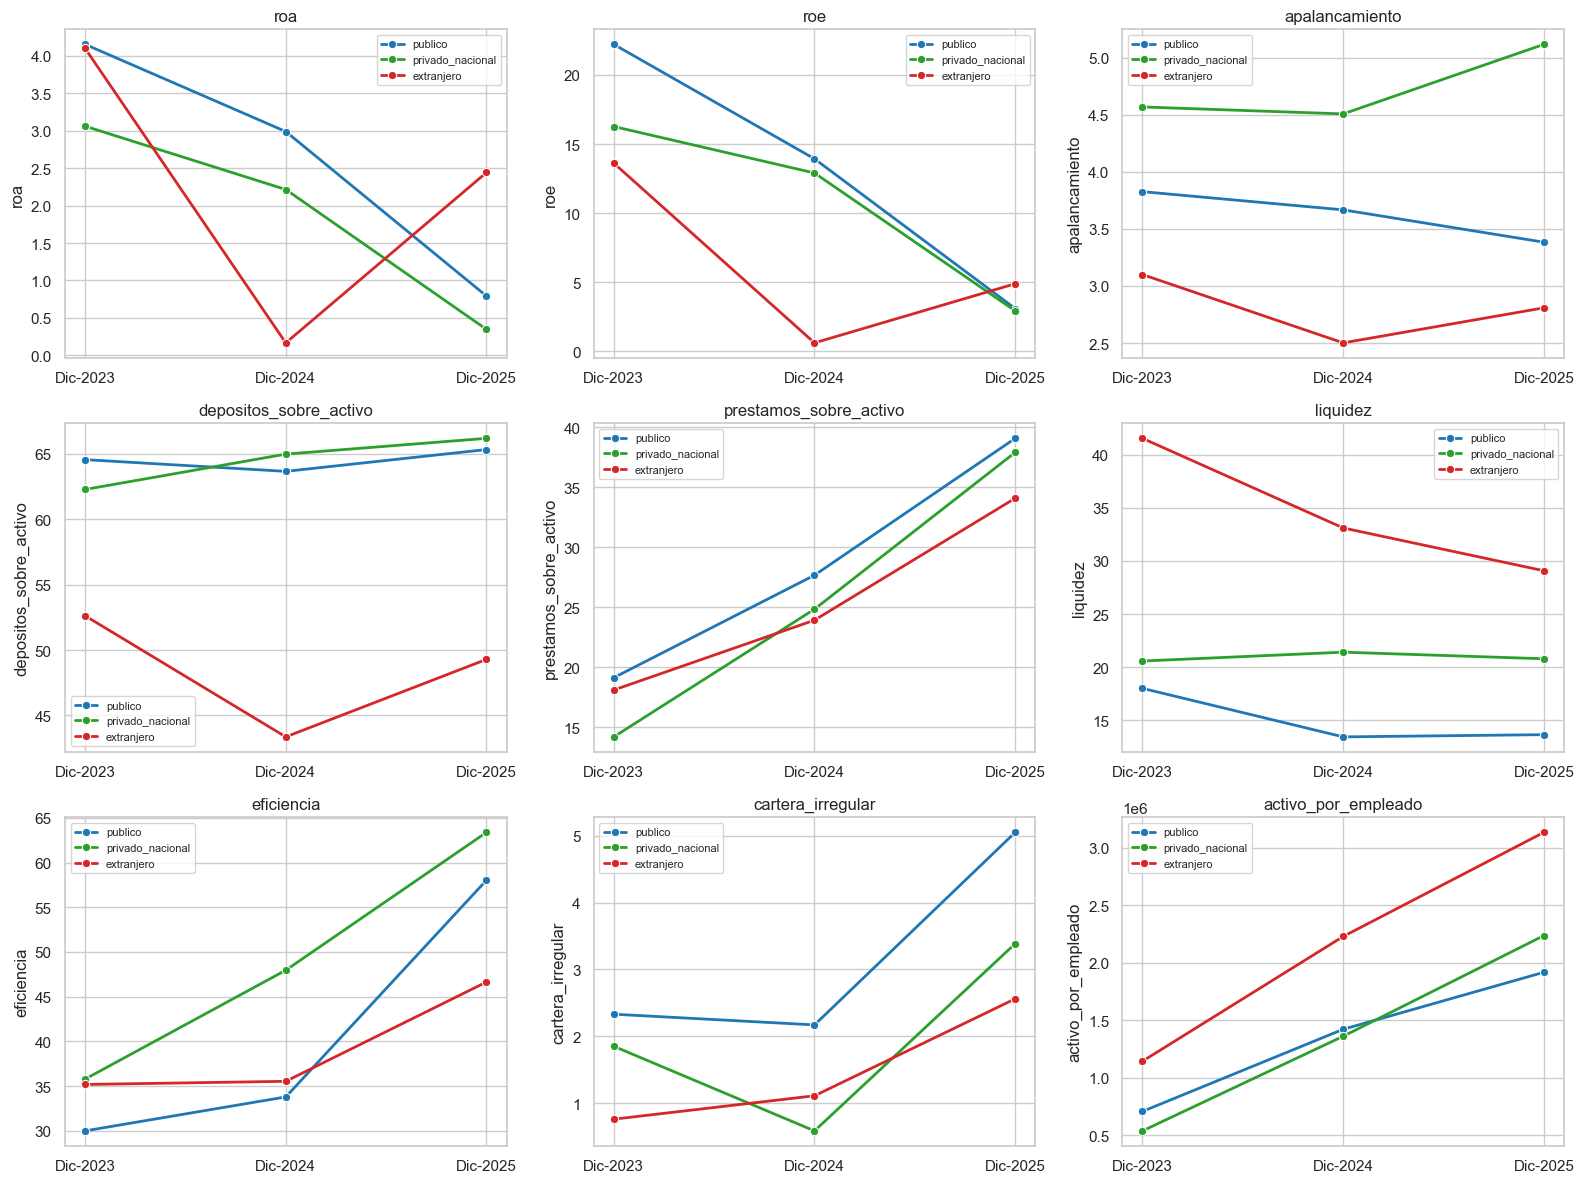

In [9]:
VARS_EVOL = [
    "roa", "roe", "apalancamiento",
    "depositos_sobre_activo", "prestamos_sobre_activo", "liquidez",
    "eficiencia", "cartera_irregular", "activo_por_empleado",
]
evol = (
    panel.groupby(["corte", "tipo_entidad"])[VARS_EVOL]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
orden_cortes = ["Dic-2023", "Dic-2024", "Dic-2025"]
for ax, var in zip(axes.flat, VARS_EVOL):
    sns.lineplot(
        data=evol, x="corte", y=var, hue="tipo_entidad",
        hue_order=ORDEN_TIPO, palette=PALETA, marker="o",
        linewidth=2, ax=ax,
    )
    ax.set_title(var)
    ax.set_xlabel("")
    ax.legend(title="", fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# Tabla resumen: medianas por tipo × corte
resumen = (
    panel.groupby(["tipo_entidad", "corte"])[VARS_EVOL]
    .median()
    .round(2)
)
resumen

roa    roe  apalancamiento  \
tipo_entidad     corte                                   
extranjero       Dic-2023  4.10  13.61            3.10   
                 Dic-2024  0.17   0.60            2.50   
                 Dic-2025  2.44   4.88            2.81   
privado_nacional Dic-2023  3.06  16.27            4.57   
                 Dic-2024  2.21  12.90            4.51   
                 Dic-2025  0.35   2.91            5.12   
publico          Dic-2023  4.15  22.22            3.83   
                 Dic-2024  2.99  13.93            3.67   
                 Dic-2025  0.79   3.08            3.38   

                           depositos_sobre_activo  prestamos_sobre_activo  \
tipo_entidad     corte                                                      
extranjero       Dic-2023                   52.63                   18.09   
                 Dic-2024                   43.36                   23.91   
                 Dic-2025                   49.29                   34.08   
privado_nacional Dic-2023                   62.29                   14.19   
                 Dic-2024                   64.99                   24.83   
                 Dic-2025                   66.20                   37.90   
publico          Dic-2023                   64.57                   19.12   
                 Dic-2024                   63.67                   27.66   
                 Dic-2025                   65.34                   39.07   

                           liquidez  eficiencia  cartera_irregular  \
tipo_entidad     corte                                               
extranjero       Dic-2023     41.53       35.19               0.76   
                 Dic-2024     33.10       35.54               1.11   
                 Dic-2025     29.08       46.64               2.56   
privado_nacional Dic-2023     20.59       35.79               1.85   
                 Dic-2024     21.42       47.96               0.58   
                 Dic-2025     20.80       63.37               3.38   
publico          Dic-2023     18.02       30.00               2.33   
                 Dic-2024     13.45       33.80               2.17   
                 Dic-2025     13.66       58.03               5.05   

                           activo_por_empleado  
tipo_entidad     corte                          
extranjero       Dic-2023           1145138.00  
                 Dic-2024           2229084.68  
                 Dic-2025           3133990.35  
privado_nacional Dic-2023            539502.84  
                 Dic-2024           1361928.53  
                 Dic-2025           2236883.72  
publico          Dic-2023            708728.93  
                 Dic-2024           1422434.63  
                 Dic-2025           1918001.45

## 7. Oferta comercial — Régimen de Transparencia

Los CSVs de transparencia (`data/raw/transparencia/`) traen los productos que cada banco **ofrece públicamente**: hipotecas, personales, prendarios, plazo fijo, tarjetas y paquetes. En el notebook 01 los agregamos a nivel banco para unirlos al master (tasa max, monto max, comisión min, etc.), pero aquí explotamos:

- **Distribuciones producto-nivel** (no banco-nivel): la dispersión de tasas dentro de un banco es parte del perfil.
- **Requisitos de acceso**: ingreso mínimo y antigüedad laboral — proxy de a qué público apunta cada banco.
- **Segmentación**: tarjetas y paquetes premium vs clásicas.
- **Cruce oferta vs balance**: ¿los bancos más rentables cobran tasas más altas?

### 7.1 Carga de CSVs producto-nivel

In [11]:
RAW_TR = Path("../data/raw/transparencia")

# Leemos cada CSV y le adjuntamos el tipo_entidad desde el master.
# Filtramos por las 56 entidades scrapeadas del BCRA (las mismas del master).
tipos_por_codigo = df24.set_index("codigo_entidad")["tipo_entidad"].to_dict()
nombres_por_codigo = df24.set_index("codigo_entidad")["nombre_banco"].to_dict()


def cargar_tr(nombre_archivo: str, col_tasa: str | None = None,
              col_comision: str | None = None) -> pd.DataFrame:
    df = pd.read_csv(RAW_TR / nombre_archivo, sep=";", encoding="latin-1")
    df = df.rename(columns={"Código de Entidad": "codigo_entidad"})
    df = df[df["codigo_entidad"].isin(tipos_por_codigo)].copy()
    df["tipo_entidad"] = df["codigo_entidad"].map(tipos_por_codigo)
    df["nombre_banco"] = df["codigo_entidad"].map(nombres_por_codigo)
    if col_tasa and col_tasa in df.columns:
        df[col_tasa] = pd.to_numeric(df[col_tasa].astype(str).str.replace(",", "."), errors="coerce")
    if col_comision and col_comision in df.columns:
        df[col_comision] = pd.to_numeric(df[col_comision].astype(str).str.replace(",", "."), errors="coerce")
    return df


tr_hipoteca = cargar_tr("HIPOTECA.CSV", "Tasa efectiva anual máxima")
tr_personal = cargar_tr("PERSONALES.CSV", "Tasa efectiva anual máxima")
tr_prendario = cargar_tr("PRENDARIOS.CSV", "Tasa efectiva anual máxima")
tr_pfijo = cargar_tr("PFIJO.CSV", "Tasa efectiva anual mínima")
tr_tarjetas = cargar_tr("TARJETAS.CSV",
                         "Tasa efectiva anual máxima de interés compensatorio por financiación de saldos",
                         "Comisión máxima por administración y mantenimiento de la cuenta")
tr_paquete = cargar_tr("PAQUETE.CSV", None,
                        "Comisión máxima por servicio de mantenimiento de paquete")

print(f"Hipoteca: {len(tr_hipoteca)} productos de {tr_hipoteca['codigo_entidad'].nunique()} bancos")
print(f"Personal: {len(tr_personal)} productos de {tr_personal['codigo_entidad'].nunique()} bancos")
print(f"Prendario: {len(tr_prendario)} productos de {tr_prendario['codigo_entidad'].nunique()} bancos")
print(f"Plazo fijo: {len(tr_pfijo)} productos de {tr_pfijo['codigo_entidad'].nunique()} bancos")
print(f"Tarjetas: {len(tr_tarjetas)} productos de {tr_tarjetas['codigo_entidad'].nunique()} bancos")
print(f"Paquete: {len(tr_paquete)} productos de {tr_paquete['codigo_entidad'].nunique()} bancos")

Hipoteca: 367 productos de 25 bancos
Personal: 536 productos de 43 bancos
Prendario: 162 productos de 19 bancos
Plazo fijo: 630 productos de 50 bancos
Tarjetas: 352 productos de 41 bancos
Paquete: 873 productos de 28 bancos


### 7.2 Distribución de tasas por producto y tipo de entidad

Cada punto es **un producto** (no un banco). Así se ve la dispersión real que enfrenta un cliente cuando shopea.

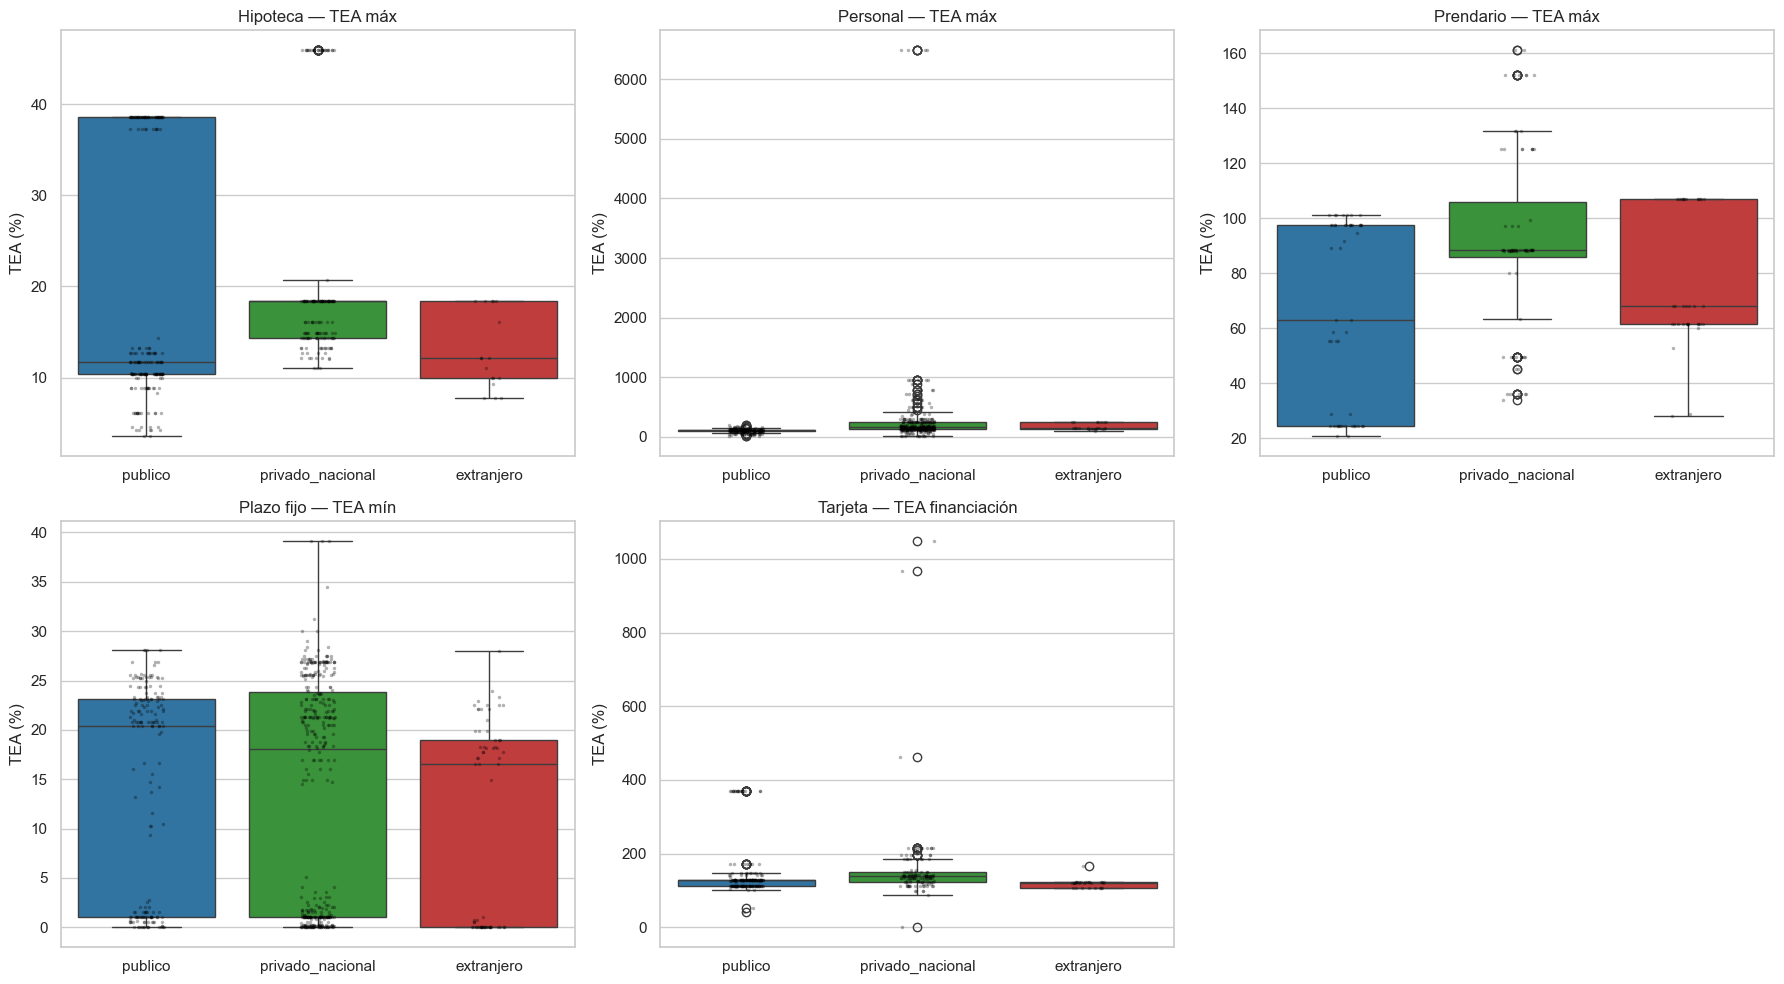

In [12]:
TASAS = [
    (tr_hipoteca, "Tasa efectiva anual máxima", "Hipoteca — TEA máx"),
    (tr_personal, "Tasa efectiva anual máxima", "Personal — TEA máx"),
    (tr_prendario, "Tasa efectiva anual máxima", "Prendario — TEA máx"),
    (tr_pfijo, "Tasa efectiva anual mínima", "Plazo fijo — TEA mín"),
    (tr_tarjetas,
     "Tasa efectiva anual máxima de interés compensatorio por financiación de saldos",
     "Tarjeta — TEA financiación"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (df_tr, col, titulo) in zip(axes.flat, TASAS):
    sub = df_tr.dropna(subset=[col])
    sns.boxplot(data=sub, x="tipo_entidad", y=col, order=ORDEN_TIPO,
                palette=PALETA, ax=ax)
    sns.stripplot(data=sub, x="tipo_entidad", y=col, order=ORDEN_TIPO,
                  color="black", size=2.5, alpha=0.3, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("TEA (%)")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

### 7.3 Requisitos de acceso

¿Cuánto ingreso mínimo y qué antigüedad laboral exigen los bancos para sus productos? Agregamos por banco (mediana de sus productos) y comparamos por tipo.

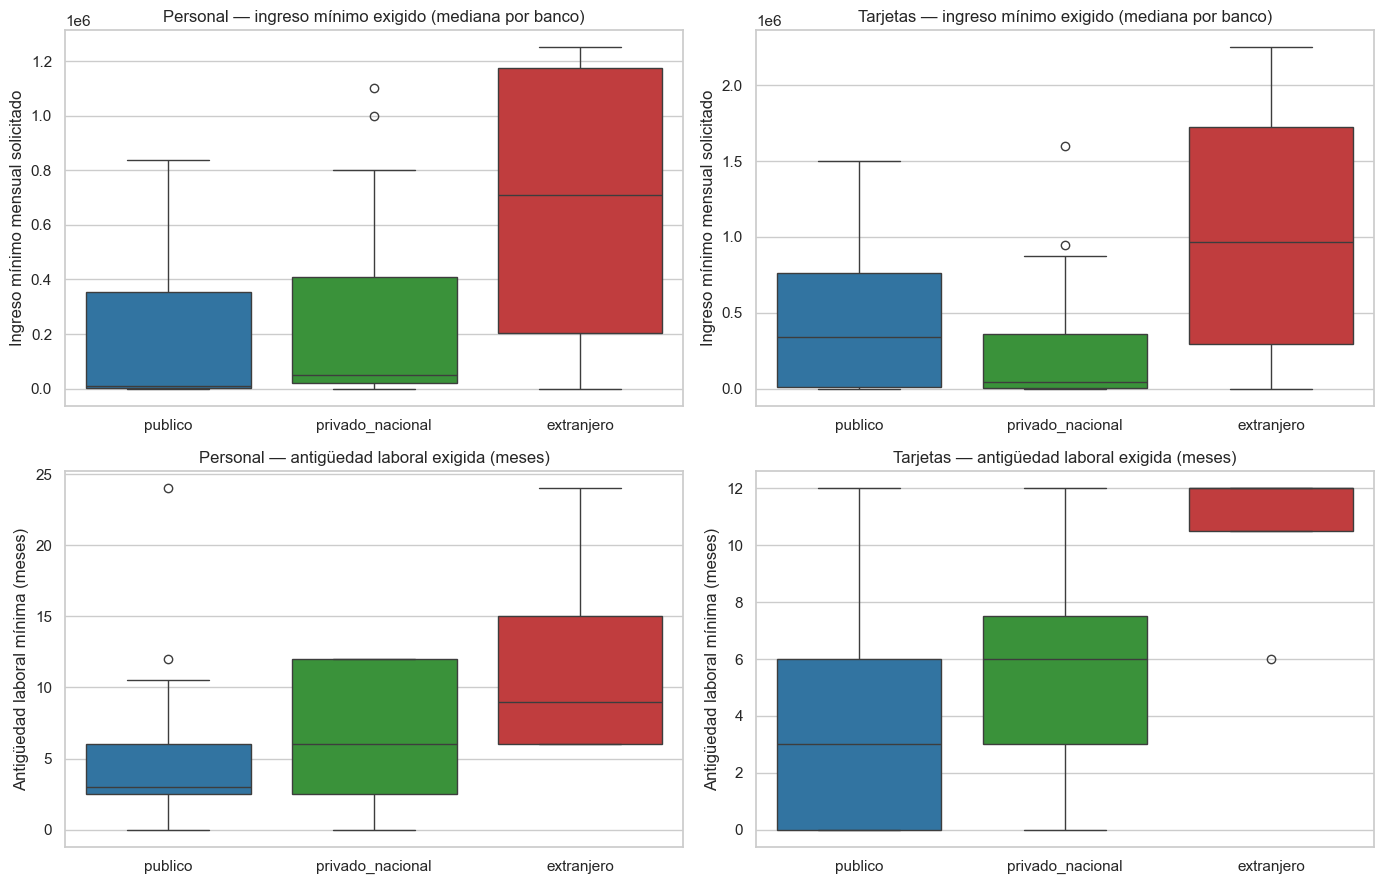

In [13]:
# Para préstamos personales y tarjetas — productos de retail más comparables.
def exigencia_por_banco(df_tr: pd.DataFrame) -> pd.DataFrame:
    cols = ["Ingreso mínimo mensual solicitado", "Antigüedad laboral mínima (meses)"]
    for c in cols:
        if c in df_tr.columns:
            df_tr[c] = pd.to_numeric(df_tr[c].astype(str).str.replace(",", "."), errors="coerce")
    return df_tr.groupby(["codigo_entidad", "tipo_entidad"])[cols].median().reset_index()


exig_personal = exigencia_por_banco(tr_personal.copy())
exig_tarjetas = exigencia_por_banco(tr_tarjetas.copy())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (df_ex, titulo) in zip(
    axes[0], [(exig_personal, "Personal"), (exig_tarjetas, "Tarjetas")]
):
    sns.boxplot(data=df_ex, x="tipo_entidad", y="Ingreso mínimo mensual solicitado",
                order=ORDEN_TIPO, palette=PALETA, ax=ax)
    ax.set_title(f"{titulo} — ingreso mínimo exigido (mediana por banco)")
    ax.set_xlabel("")
for ax, (df_ex, titulo) in zip(
    axes[1], [(exig_personal, "Personal"), (exig_tarjetas, "Tarjetas")]
):
    sns.boxplot(data=df_ex, x="tipo_entidad", y="Antigüedad laboral mínima (meses)",
                order=ORDEN_TIPO, palette=PALETA, ax=ax)
    ax.set_title(f"{titulo} — antigüedad laboral exigida (meses)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 7.4 Segmentación — tarjetas y paquetes premium

El campo `Segmento` clasifica la oferta (clásica / gold / platinum / black / joven / etc.). Miramos la proporción de oferta premium por tipo de entidad.

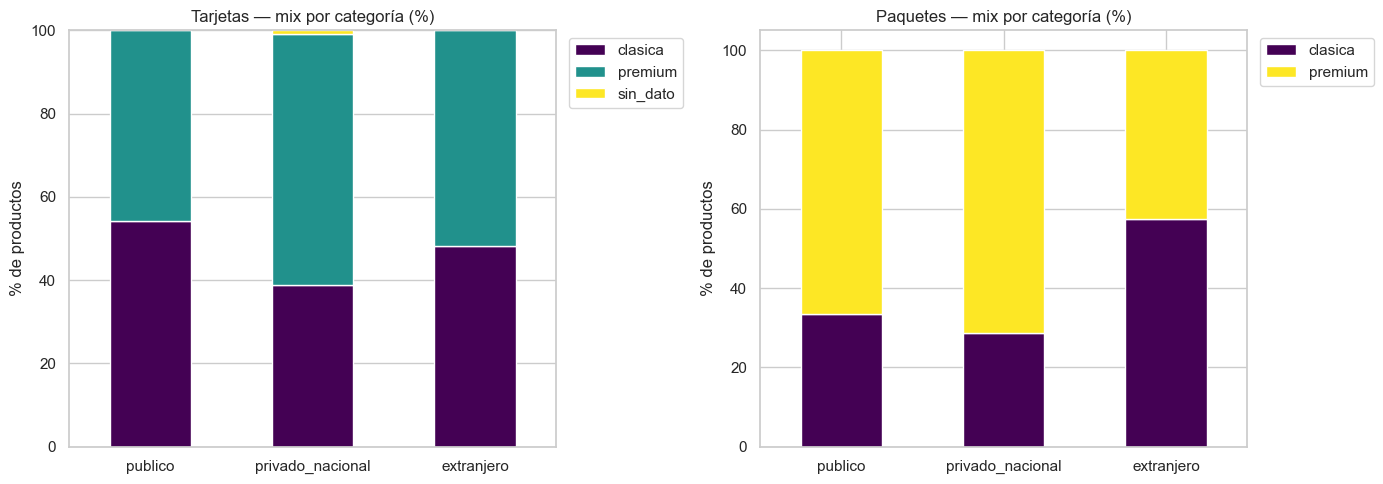

Cantidades absolutas — tarjetas:
categoria         clasica  premium  sin_dato
tipo_entidad                                
publico               105       89         0
privado_nacional       50       78         1
extranjero             14       15         0

Cantidades absolutas — paquetes:
categoria         clasica  premium
tipo_entidad                      
publico               160      318
privado_nacional       81      201
extranjero             65       48


In [14]:
def clasificar_premium(seg: str) -> str:
    if not isinstance(seg, str):
        return "sin_dato"
    s = seg.lower()
    if any(k in s for k in ["platinum", "black", "signature", "infinite", "premium"]):
        return "premium"
    if "gold" in s or "oro" in s:
        return "gold"
    return "clasica"


tr_tarjetas["categoria"] = tr_tarjetas["Segmento"].apply(clasificar_premium)
tr_paquete["categoria"] = tr_paquete["Segmento"].apply(clasificar_premium)

mix_tarjetas = (
    tr_tarjetas.groupby(["tipo_entidad", "categoria"]).size()
    .unstack(fill_value=0)
    .reindex(ORDEN_TIPO)
)
mix_paquete = (
    tr_paquete.groupby(["tipo_entidad", "categoria"]).size()
    .unstack(fill_value=0)
    .reindex(ORDEN_TIPO)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(mix_tarjetas.div(mix_tarjetas.sum(axis=1), axis=0) * 100).plot(
    kind="bar", stacked=True, ax=axes[0], colormap="viridis"
)
axes[0].set_title("Tarjetas — mix por categoría (%)")
axes[0].set_ylabel("% de productos")
axes[0].set_xlabel("")
axes[0].legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=0)
(mix_paquete.div(mix_paquete.sum(axis=1), axis=0) * 100).plot(
    kind="bar", stacked=True, ax=axes[1], colormap="viridis"
)
axes[1].set_title("Paquetes — mix por categoría (%)")
axes[1].set_ylabel("% de productos")
axes[1].set_xlabel("")
axes[1].legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Cantidades absolutas — tarjetas:")
print(mix_tarjetas)
print("\nCantidades absolutas — paquetes:")
print(mix_paquete)

### 7.5 Variedad de oferta — productos únicos por banco

No es lo mismo "ofrecer préstamos personales" que ofrecer 15 variantes distintas. Contamos productos únicos por banco en cada categoría.

In [15]:
variedad = pd.DataFrame({
    "hipoteca": tr_hipoteca.groupby("codigo_entidad").size(),
    "personal": tr_personal.groupby("codigo_entidad").size(),
    "prendario": tr_prendario.groupby("codigo_entidad").size(),
    "pfijo": tr_pfijo.groupby("codigo_entidad").size(),
    "tarjetas": tr_tarjetas.groupby("codigo_entidad").size(),
    "paquetes": tr_paquete.groupby("codigo_entidad").size(),
}).fillna(0).astype(int)
variedad["tipo_entidad"] = variedad.index.map(tipos_por_codigo)

# Medianas por tipo
variedad_mediana = variedad.groupby("tipo_entidad").median().reindex(ORDEN_TIPO)
variedad_mediana

,hipoteca,personal,prendario,pfijo,tarjetas,paquetes
tipo_entidad,,,,,,
publico,2.0,5.5,0.0,9.0,6.5,3.5
privado_nacional,0.0,4.0,0.0,11.0,3.0,0.0
extranjero,1.0,4.0,2.0,3.5,4.5,1.5


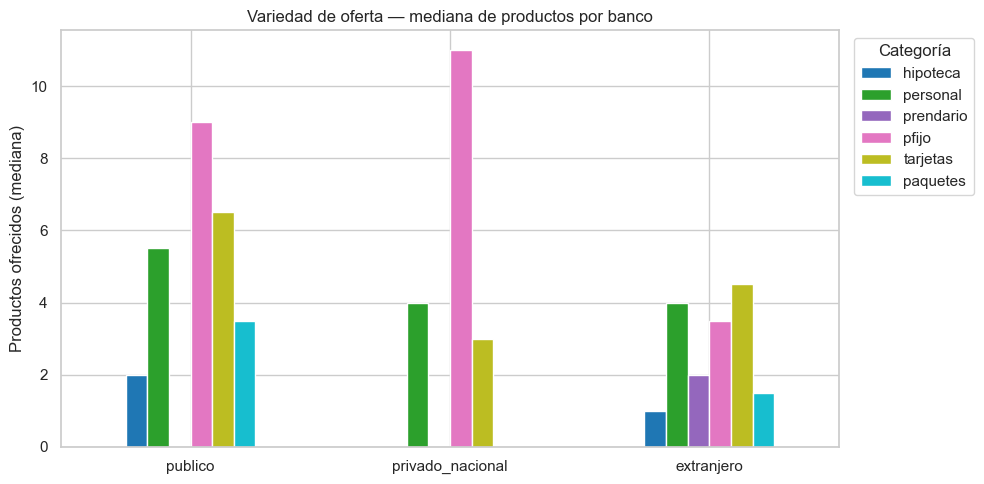

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
variedad_mediana.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Variedad de oferta — mediana de productos por banco")
ax.set_ylabel("Productos ofrecidos (mediana)")
ax.set_xlabel("")
ax.legend(title="Categoría", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 7.6 Cruce: oferta comercial vs balance

¿Los bancos más rentables o más grandes exhiben tasas más altas, cobran más comisiones o exigen más? Unimos las tasas y comisiones agregadas a nivel banco con los ratios del master.

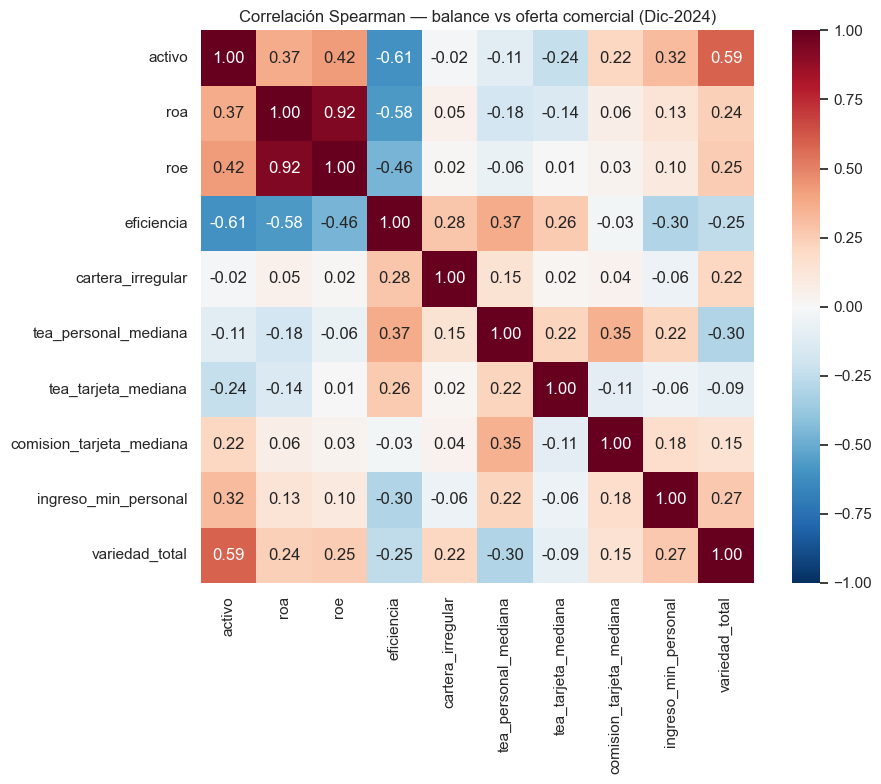

In [17]:
oferta_banco = pd.DataFrame({
    "tea_personal_mediana": tr_personal.groupby("codigo_entidad")["Tasa efectiva anual máxima"].median(),
    "tea_tarjeta_mediana": tr_tarjetas.groupby("codigo_entidad")[
        "Tasa efectiva anual máxima de interés compensatorio por financiación de saldos"
    ].median(),
    "comision_tarjeta_mediana": tr_tarjetas.groupby("codigo_entidad")[
        "Comisión máxima por administración y mantenimiento de la cuenta"
    ].median(),
    "ingreso_min_personal": tr_personal.groupby("codigo_entidad")[
        "Ingreso mínimo mensual solicitado"
    ].median(),
    "variedad_total": variedad[["hipoteca", "personal", "prendario",
                                  "pfijo", "tarjetas", "paquetes"]].sum(axis=1),
})

cruce = df24[["codigo_entidad", "nombre_banco", "tipo_entidad",
              "activo", "roa", "roe", "eficiencia",
              "cartera_irregular"]].merge(
    oferta_banco, left_on="codigo_entidad", right_index=True, how="left"
)

cols_corr = ["activo", "roa", "roe", "eficiencia", "cartera_irregular",
             "tea_personal_mediana", "tea_tarjeta_mediana",
             "comision_tarjeta_mediana", "ingreso_min_personal", "variedad_total"]
corr_of = cruce[cols_corr].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_of, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación Spearman — balance vs oferta comercial (Dic-2024)")
plt.tight_layout()
plt.show()

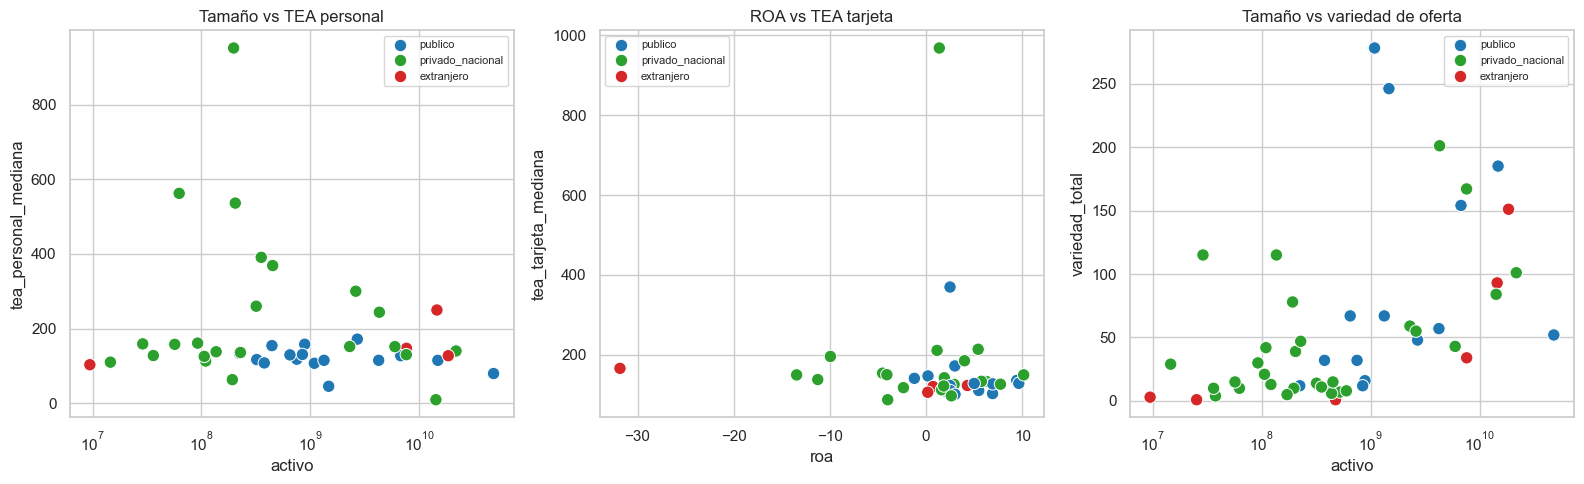

In [18]:
# Scatters ilustrativos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=cruce, x="activo", y="tea_personal_mediana",
                hue="tipo_entidad", palette=PALETA, hue_order=ORDEN_TIPO,
                s=80, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Tamaño vs TEA personal")
axes[0].legend(fontsize=8)

sns.scatterplot(data=cruce, x="roa", y="tea_tarjeta_mediana",
                hue="tipo_entidad", palette=PALETA, hue_order=ORDEN_TIPO,
                s=80, ax=axes[1])
axes[1].set_title("ROA vs TEA tarjeta")
axes[1].legend(fontsize=8)

sns.scatterplot(data=cruce, x="activo", y="variedad_total",
                hue="tipo_entidad", palette=PALETA, hue_order=ORDEN_TIPO,
                s=80, ax=axes[2])
axes[2].set_xscale("log")
axes[2].set_title("Tamaño vs variedad de oferta")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 7.7 Takeaways de oferta comercial

Los datos quedan guardados en `oferta_banco` (agregado a nivel banco) y `variedad` (variedad de productos) para ser integrados al panel del notebook 03 de clustering.

## 8. Validaciones y análisis complementarios

Antes de pasar al clustering (notebook 03) cerramos tres frentes:

- **Bugs detectados en la primera pasada del EDA** (signo de la eficiencia, anualización del resultado en Dic-2025, cartera irregular de extranjeros).
- **Respaldo estadístico** para la afirmación "los tres tipos de entidad son distinguibles" — Kruskal-Wallis por ratio.
- **Concentración del sistema** (HHI, share del top-5) y diagnóstico de missings por banco, para decidir exclusiones del clustering.

### 8.1 Inspección de signos crudos en el estado contable

En la primera corrida la eficiencia daba negativa para los tres tipos (-13% / -17% / -20%) cuando el ratio estándar vive en ~40-80% positivo. Inspeccionamos los valores crudos de las cuatro columnas del margen para tres bancos representativos — confirmamos que el BCRA publica los egresos y gastos con signo negativo, así que el fix está en tomar valor absoluto antes de combinar.

In [19]:
cols_signo = [
    "nombre_banco", "tipo_entidad",
    "INGRESOS FINANCIEROS", "EGRESOS FINANCIEROS",
    "INGRESOS POR SERVICIOS", "EGRESOS POR SERVICIOS",
    "GASTOS DE ADMINISTRACIÓN",
    "R D O S. I N T E G R A L E S A C U M. D E L P E R I O D O",
]
raw24 = pd.read_csv(PROC / "dataset_master_dic2024.csv")
muestra = raw24[raw24["nombre_banco"].str.contains(
    "NACION|SANTANDER|BNP", case=False, na=False)][cols_signo]
muestra.set_index("nombre_banco").T

nombre_banco,BANCO DE LA NACION ARGENTINA,BANCO SANTANDER ARGENTINA S.A.,BNP PARIBAS
tipo_entidad,publico,extranjero,extranjero
INGRESOS FINANCIEROS,25345942955.0,6390586473.0,99382540.0
EGRESOS FINANCIEROS,-9985219093.0,-2589306226.0,-24056275.0
INGRESOS POR SERVICIOS,495424728.0,956032185.0,14730686.0
EGRESOS POR SERVICIOS,-453293832.0,-433389595.0,-993768.0
GASTOS DE ADMINISTRACIÓN,-1788302150.0,-1346634137.0,-29153789.0
R D O S. I N T E G R A L E S A C U M. D E L P E R I O D O,3313035071.0,790081200.0,12609136.0


Los egresos financieros, los egresos por servicios y los gastos de administración vienen con signo negativo (entre paréntesis en las tablas HTML del BCRA). En `construir_ratios` aplicamos `abs()` sobre esas columnas antes de combinarlas, lo que devuelve la eficiencia al rango esperado (ver tabla de medianas por tipo en §4.2).

### 8.2 ¿El resultado de Dic-2025 está anualizado?

La caída de ROA entre Dic-24 y Dic-25 parecía sospechosa. Si el campo `R D O S. I N T E G R A L E S A C U M. D E L P E R I O D O` viniera mensualizado en Dic-25, deberíamos observar un ratio sistemático de ~11/12 ≈ 0.92 en el resultado Dic-25 / Dic-24 para los bancos más grandes. Chequeamos el top-5 por activo.

In [20]:
top5 = masters["dic2024"].nlargest(5, "activo")[
    ["codigo_entidad", "nombre_banco", "activo", "resultado", "ing_fin"]
].copy()
top5 = top5.rename(columns={"activo": "act_24", "resultado": "res_24", "ing_fin": "ing_24"})

d25_flat = masters["dic2025"][["codigo_entidad", "activo", "resultado", "ing_fin"]].rename(
    columns={"activo": "act_25", "resultado": "res_25", "ing_fin": "ing_25"}
)
chk_2025 = top5.merge(d25_flat, on="codigo_entidad")
chk_2025["ratio_res_25_24"] = chk_2025["res_25"] / chk_2025["res_24"]
chk_2025["ratio_ing_25_24"] = chk_2025["ing_25"] / chk_2025["ing_24"]
chk_2025["ratio_act_25_24"] = chk_2025["act_25"] / chk_2025["act_24"]
chk_2025[["nombre_banco", "res_24", "res_25",
          "ratio_res_25_24", "ratio_ing_25_24", "ratio_act_25_24"]].round(3)

,nombre_banco,res_24,res_25,ratio_res_25_24,ratio_ing_25_24,ratio_act_25_24
0,BANCO DE LA NACION ARGENTINA,3.313035e+09,1.190434e+09,0.359,0.682,1.443
1,BANCO DE GALICIA Y BUENOS AIRES S.A,1.359485e+09,-1.018485e+08,-0.075,1.030,1.690
2,BANCO SANTANDER ARGENTINA S.A.,7.900812e+08,6.802798e+08,0.861,0.935,1.351
3,BANCO DE LA PROVINCIA DE BUENOS AIR,2.850275e+07,1.287789e+07,0.452,0.743,1.300
4,BANCO BBVA ARGENTINA S.A.,2.425234e+07,1.579357e+08,6.512,1.080,1.694


Los ratios `res_25/res_24` son muy heterogéneos entre bancos (del orden de 0.07 a 6.5) y no se concentran en ~0.92. Descartamos el escenario "Dic-2025 viene en 11/12 avos": el corte que trae el BCRA en `dataset_master_dic2025.csv` corresponde al cierre anual, y la caída del ROA mediana entre 2024 y 2025 es un resultado real del sistema, no un artefacto de anualización.

### 8.3 Cartera irregular en extranjeros — diagnóstico

La mediana de cartera irregular de los 9 extranjeros daba exactamente 0%. Antes de leer eso como "mejor calidad de cartera", verificamos cuántos de esos bancos efectivamente tienen cartera minorista. Los que no tienen financiaciones reportadas (bancos mayoristas / de inversión) no deben entrar al denominador del grupo.

In [21]:
ext24 = masters["dic2024"][masters["dic2024"]["tipo_entidad"] == "extranjero"].copy()
diag_ext = ext24[[
    "nombre_banco",
    "financiaciones_totales",
    "TF.Sit.3: Con problemas/Riesgo medio (%)",
    "TF.Sit.4: Con alto riesgo de insolvencia/Riesgo alto (%)",
    "TF.Sit.5: Irrecuperable (%)",
    "cartera_irregular",
]].copy()
diag_ext["aplica"] = diag_ext["financiaciones_totales"].fillna(0) > 0
diag_ext.sort_values("aplica", ascending=False)

,nombre_banco,financiaciones_totales,TF.Sit.3: Con problemas/Riesgo medio (%),TF.Sit.4: Con alto riesgo de insolvencia/Riesgo alto (%),TF.Sit.5: Irrecuperable (%),cartera_irregular,aplica
3,INDUSTRIAL AND COMMERCIAL BANK OF C,2971753.41,0.68,0.36,0.07,1.11,True
4,CITIBANK N.A.,847509.09,NaN,0.00,NaN,0.00,True
5,BANCO BBVA ARGENTINA S.A.,7657531.00,0.64,0.46,0.06,1.16,True
13,BANCO SANTANDER ARGENTINA S.A.,8211585.82,0.56,1.20,0.11,1.87,True
19,BANK OF CHINA LIMITED SUCURSAL BUEN,16269.62,NaN,NaN,NaN,NaN,True
22,"JPMORGAN CHASE BANK, NATIONAL ASSOC",66583.22,NaN,NaN,NaN,NaN,True
27,BNP PARIBAS,22173.20,NaN,NaN,NaN,NaN,True
29,BANCO DE LA REPUBLICA ORIENTAL DEL,237.08,0.09,0.00,0.00,0.09,True
44,BANCO CETELEM ARGENTINA S.A.,2127.78,NaN,NaN,NaN,NaN,True


De los 9 extranjeros, solo los que tienen `financiaciones_totales > 0` aportan una lectura válida de cartera irregular. A los restantes (mayoristas/inversión) `construir_ratios` les asigna `NaN` en `cartera_irregular`, de modo que la mediana del grupo se calcula solo sobre los bancos donde la métrica aplica. Recalculamos acá la mediana por tipo con la corrección ya aplicada:

In [22]:
masters["dic2024"].groupby("tipo_entidad")["cartera_irregular"].agg(
    ["count", "median", "mean"]
).reindex(ORDEN_TIPO).round(2)

,count,median,mean
tipo_entidad,,,
publico,17,2.17,2.55
privado_nacional,30,0.58,2.60
extranjero,5,1.11,0.85


### 8.4 Kruskal-Wallis — ¿los tres tipos de entidad son distinguibles?

Con n=9 extranjeros conviene un test no paramétrico. Corremos Kruskal-Wallis por variable sobre Dic-2024 — la hipótesis nula es "las tres distribuciones vienen del mismo población". p-valor bajo ⇒ al menos un tipo difiere.

In [23]:
from scipy import stats

VARS_KW = [
    "roa", "roe", "apalancamiento",
    "depositos_sobre_activo", "cartera_irregular",
    "liquidez", "activo_por_empleado", "n_productos_ofrecidos",
]

filas = []
for var in VARS_KW:
    grupos = [
        df24.loc[df24["tipo_entidad"] == t, var].dropna().values
        for t in ORDEN_TIPO
    ]
    n_por_grupo = [len(g) for g in grupos]
    if all(len(g) >= 2 for g in grupos):
        H, p = stats.kruskal(*grupos)
    else:
        H, p = float("nan"), float("nan")
    filas.append({
        "variable": var,
        "n_publico": n_por_grupo[0],
        "n_privado_nac": n_por_grupo[1],
        "n_extranjero": n_por_grupo[2],
        "H": round(H, 2) if pd.notna(H) else None,
        "p_valor": round(p, 4) if pd.notna(p) else None,
        "significativo_5pct": (p < 0.05) if pd.notna(p) else None,
    })
kw = pd.DataFrame(filas)
kw

,variable,n_publico,n_privado_nac,n_extranjero,H,p_valor,significativo_5pct
0,roa,17,30,9,6.85,0.0325,True
1,roe,17,30,9,6.20,0.0451,True
2,apalancamiento,17,30,9,9.10,0.0106,True
3,depositos_sobre_activo,17,30,8,3.95,0.1386,False
4,cartera_irregular,17,30,5,6.67,0.0356,True
5,liquidez,17,30,8,13.33,0.0013,True
6,activo_por_empleado,17,30,9,1.65,0.4391,False
7,n_productos_ofrecidos,17,30,9,6.43,0.0401,True


Las variables con p < 0.05 son las que efectivamente separan perfiles y son buenas candidatas a entrar al clustering con peso pleno. Las que dan p > 0.05 no necesariamente se descartan (pueden aportar en combinación con otras), pero no respaldan por sí solas la afirmación de que los tres perfiles difieran en esa dimensión.

### 8.5 Concentración del sistema — HHI y share del top-5

Dos medidas clásicas de concentración sobre el activo:

- **HHI**: suma de cuadrados de los shares individuales. Convención DoJ: <1500 mercado competitivo, 1500-2500 moderadamente concentrado, >2500 altamente concentrado. Lo expresamos en base 10000.
- **Share del top-5**: qué porción del activo del sistema explican los 5 bancos más grandes.

Mostramos los tres cortes para ver si la concentración se movió.

In [24]:
def hhi_y_top5(df: pd.DataFrame) -> dict:
    tot = df["activo"].sum()
    shares = df["activo"] / tot
    hhi = float((shares ** 2).sum() * 10000)
    top5_share = float(df.nlargest(5, "activo")["activo"].sum() / tot * 100)
    return {"HHI": round(hhi, 1), "top5_share_pct": round(top5_share, 2)}


concentracion = pd.DataFrame(
    {CORTE_LABEL[c]: hhi_y_top5(masters[c]) for c in CORTES}
).T
concentracion

,HHI,top5_share_pct
Dic-2023,1005.0,59.11
Dic-2024,1047.9,59.88
Dic-2025,1055.6,61.36


### 8.6 Missings por banco — ¿quién conviene excluir del clustering?

El análisis por variable de la §1 muestra qué columnas tienen más huecos. Acá invertimos la mirada: sobre cada banco, qué fracción del set candidato al clustering (ratios + oferta comercial) está vacía. Los bancos con demasiados missings van a traer ruido a cualquier imputación.

In [25]:
VARS_CLUSTER = [
    "roa", "roe", "apalancamiento",
    "depositos_sobre_activo", "prestamos_sobre_activo",
    "liquidez", "eficiencia", "cartera_irregular",
    "activo_por_empleado", "n_productos_ofrecidos",
]

# Sumamos features de oferta agregada (se calculan más abajo en §7.6, así que
# los traemos desde oferta_banco si ya está disponible).
cruce24 = df24.set_index("codigo_entidad").copy()
if "oferta_banco" in globals():
    cruce24 = cruce24.join(oferta_banco, how="left")
    VARS_CLUSTER_FULL = VARS_CLUSTER + list(oferta_banco.columns)
else:
    VARS_CLUSTER_FULL = VARS_CLUSTER

miss_banco = cruce24[VARS_CLUSTER_FULL].isna().mean(axis=1) * 100
miss_banco = miss_banco.to_frame("pct_missing").join(
    cruce24[["nombre_banco", "tipo_entidad"]]
)
top10_missings = miss_banco.sort_values("pct_missing", ascending=False).head(10)
top10_missings.round(1)

,pct_missing,nombre_banco,tipo_entidad
codigo_entidad,,,
331,53.3,BANCO CETELEM ARGENTINA S.A.,extranjero
266,40.0,BNP PARIBAS,extranjero
131,40.0,BANK OF CHINA LIMITED SUCURSAL BUEN,extranjero
300,33.3,BANCO DE INVERSION Y COMERCIO EXTER,publico
16,33.3,CITIBANK N.A.,extranjero
198,33.3,BANCO DE VALORES S.A.,privado_nacional
165,33.3,"JPMORGAN CHASE BANK, NATIONAL ASSOC",extranjero
319,26.7,BANCO CMF S.A.,privado_nacional
254,26.7,BANCO MARIVA S.A.,privado_nacional


**Criterio de exclusión propuesto para el notebook 03**: bancos con más del 40% de missings sobre el set del clustering. Son típicamente sucursales mayoristas / de inversión (BNP, JPMorgan, Bank of China, Citelem) que no reportan cartera minorista ni publican productos en transparencia — no tiene sentido forzarlos a un perfil junto a bancos retail. La decisión final queda documentada en el notebook 03 y se ejecuta al armar la matriz de features.

In [26]:
umbral_exclusion = 40
excluir = miss_banco[miss_banco["pct_missing"] > umbral_exclusion]
print(f"Bancos con >{umbral_exclusion}% de missings sobre {len(VARS_CLUSTER_FULL)} "
      f"variables candidatas:")
excluir.sort_values("pct_missing", ascending=False).round(1)

Bancos con >40% de missings sobre 15 variables candidatas:


,pct_missing,nombre_banco,tipo_entidad
codigo_entidad,,,
331,53.3,BANCO CETELEM ARGENTINA S.A.,extranjero


## 6. Artefactos

Guardamos el panel transversal con ratios para el notebook de clustering (03).

In [27]:
out_panel = PROC / "panel_ratios.csv"
panel.to_csv(out_panel, index=False)
print(f"Guardado: {out_panel}  shape={panel.shape}")

# Exportamos también la oferta agregada y la variedad — el notebook 03 los
# necesita para sumar features de transparencia al clustering.
out_oferta = PROC / "oferta_banco.csv"
oferta_banco.to_csv(out_oferta)
print(f"Guardado: {out_oferta}  shape={oferta_banco.shape}")

out_variedad = PROC / "variedad_productos.csv"
variedad.to_csv(out_variedad)
print(f"Guardado: {out_variedad}  shape={variedad.shape}")

Guardado: ../data/processed/panel_ratios.csv  shape=(168, 157)
Guardado: ../data/processed/oferta_banco.csv  shape=(51, 5)
Guardado: ../data/processed/variedad_productos.csv  shape=(51, 7)
